C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8268\1713422779.py:6: DtypeWarning: Columns (10,36,37,38,39,40,41,43,44,46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("D:/Study in SU/Herring study/Herring from GBIF .csv",sep="\t")


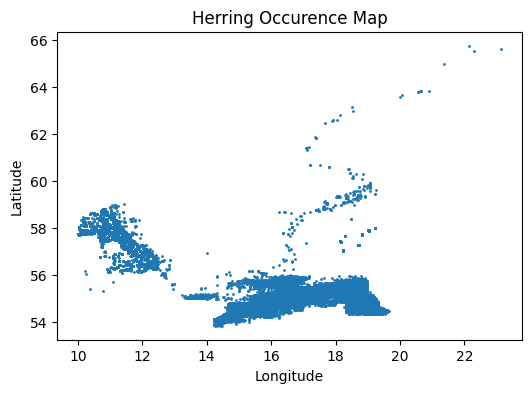

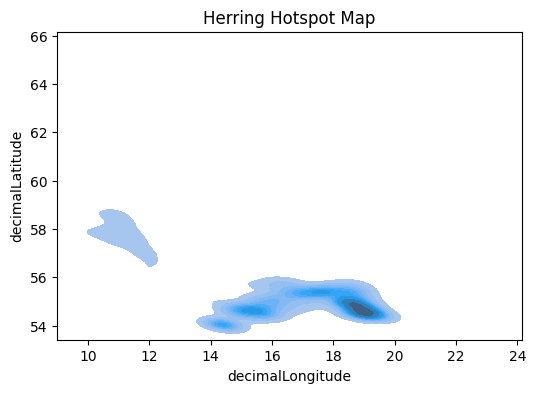

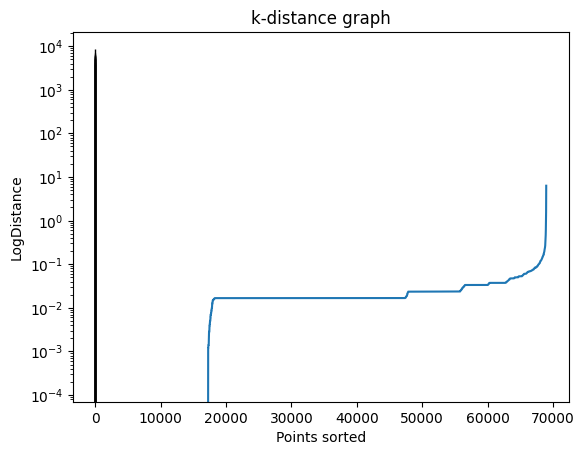

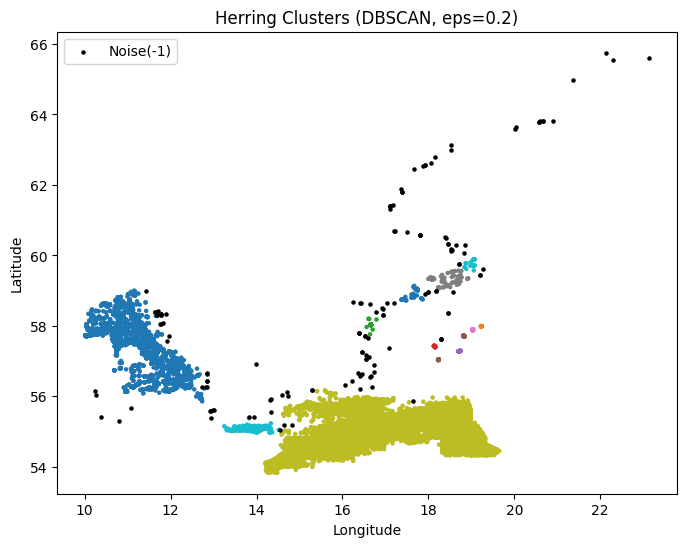


 === eps=0.2===
cluster
 10    63637
 0      4394
 12      194
 3       162
-1       143
 1        81
 9        78
 5        47
 2        46
 4        40
 6        39
 11       37
 8        30
 7        27
Name: count, dtype: int64


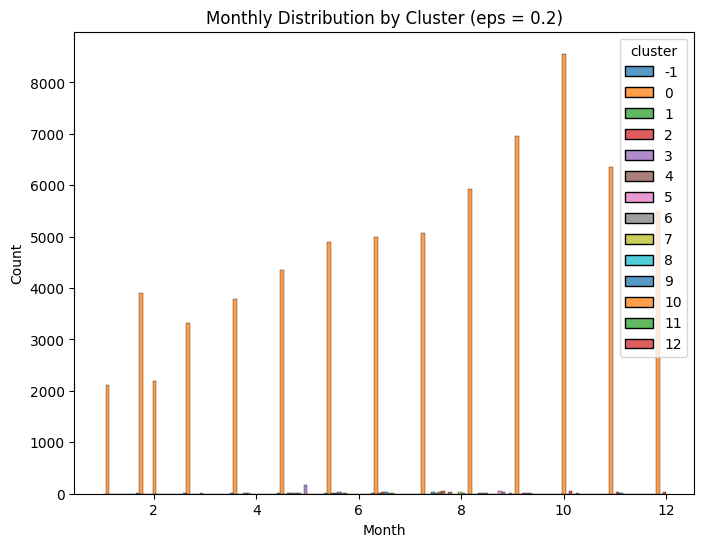

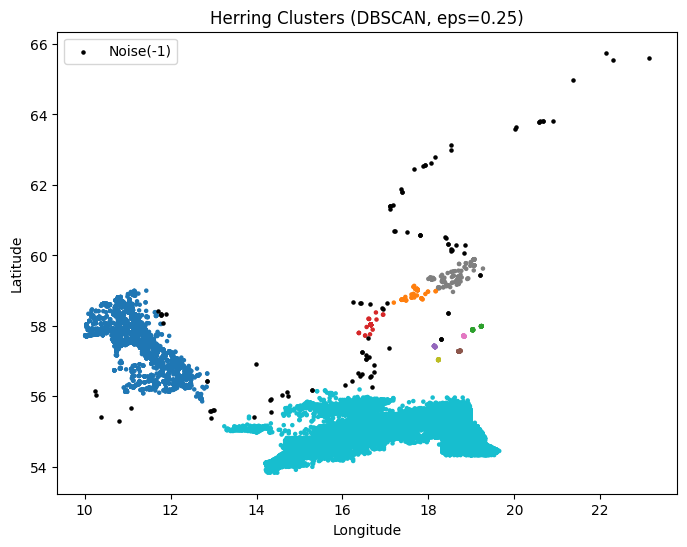


 === eps=0.25===
cluster
 9    63837
 0     4408
 3      170
 7      119
-1      105
 1       87
 2       76
 5       47
 4       40
 6       39
 8       27
Name: count, dtype: int64


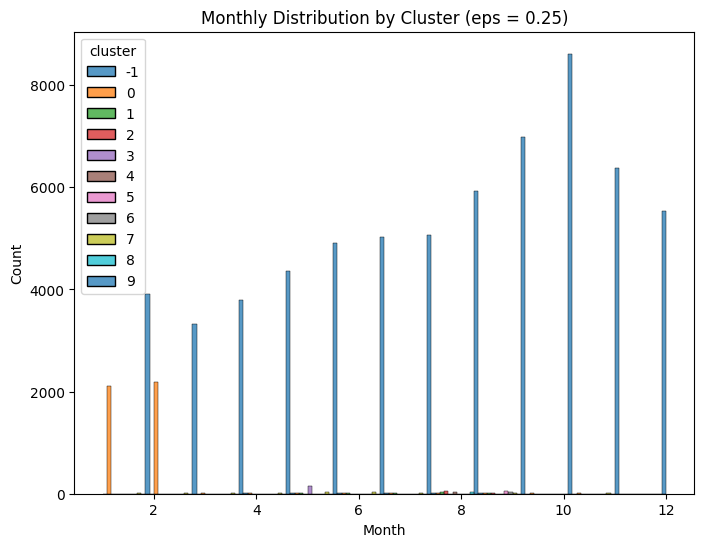

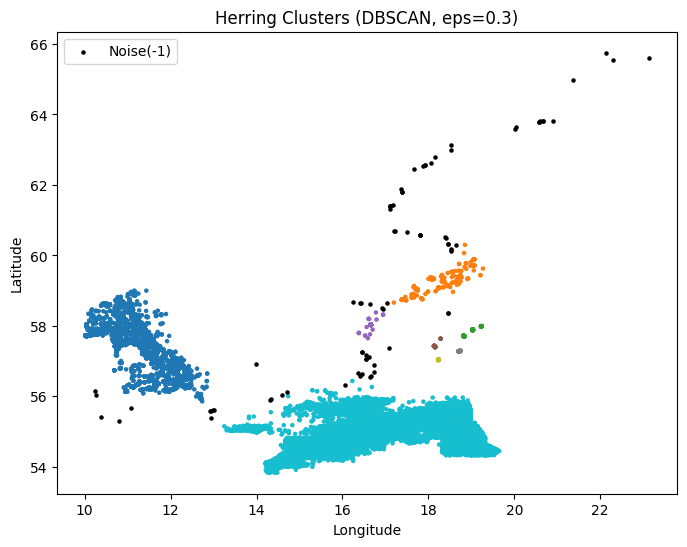


 === eps=0.3===
cluster
 7    63844
 0     4417
 1      211
 3      171
 2      115
-1       80
 5       47
 4       43
 6       27
Name: count, dtype: int64


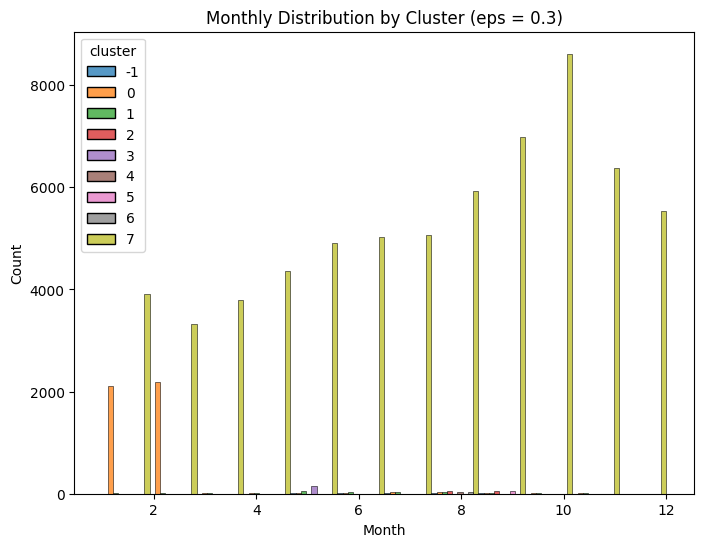

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import numpy as np
df = pd.read_csv("D:/Study in SU/Herring study/Herring from GBIF .csv",sep="\t")
df.head()
df.columns

df= df[[
    'decimalLatitude','decimalLongitude','eventDate','countryCode'
]]

df = df.dropna(subset=['decimalLatitude','decimalLongitude'])

df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')

df = df.dropna(subset=['eventDate'])

df = df[
    (df['decimalLatitude'] > 53) &
    (df['decimalLatitude'] < 66) &
    (df['decimalLongitude'] > 10) &
    (df['decimalLongitude'] < 30)
]
df['month'] = df['eventDate'].dt.month
df['year'] = df['eventDate'].dt.year

plt.figure(figsize=(6,4))
plt.scatter(df['decimalLongitude'], df['decimalLatitude'], s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Herring Occurence Map')

plt.savefig('figures/occurrence_map.png', dpi=300)
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(
    x=df['decimalLongitude'],
    y=df['decimalLatitude'],
    fill=True
)
plt.title('Herring Hotspot Map')

plt.savefig('figures/hotspot_map.png', dpi=300)
plt.show()

sns.histplot(df['month'], bins=12)
plt.title('Monthly Distribution of Herring')

from sklearn.cluster import DBSCAN

coords = df[['decimalLatitude', 'decimalLongitude']]
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(coords)
distances, indices = neighbors_fit.kneighbors(coords)

distances = np.sort(distances[:,19])

plt.plot(distances)
plt.yscale('log')
plt.title('k-distance graph')
plt.xlabel('Points sorted')
plt.ylabel('LogDistance')

plt.savefig('figures/distribution.png',dpi=300)
plt.show()

for eps in [0.2,0.25,0.3]:
    model = DBSCAN(eps=eps, min_samples= 20)
    df['cluster'] = model.fit_predict(coords)
    
    plt.figure(figsize=(8,6))
    df_main = df[df['cluster'] != -1]
    plt.scatter(
    df_main['decimalLongitude'],
    df_main['decimalLatitude'],
    c=df_main['cluster'],
    s=5,
    cmap='tab10'
)
    df_noise = df[df['cluster'] == -1]
    plt.scatter(
    df_noise['decimalLongitude'],
    df_noise['decimalLatitude'],
    color='black',
    s=5,
    label = 'Noise(-1)'
)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Herring Clusters (DBSCAN, eps={eps})')
    plt.legend()
    plt.savefig(f'figures/clusters_eps_{eps}.png',dpi=300)
    plt.show()
    print(f'\n === eps={eps}===')
    print(df['cluster'].value_counts())
    plt.figure(figsize=(8,6))
    sns.histplot(
    data=df,
    x='month',
    hue='cluster',
    bins=12,
    multiple='dodge',
    palette='tab10'
)
    plt.title(f'Monthly Distribution by Cluster (eps = {eps})')
    plt.xlabel('Month')
    plt.savefig(f'figures/monthly_distribution_eps_{eps}.png',dpi=300)
    plt.show()


